In [ ]:
#experiment 1
!pip install dwave-ocean-sdk --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.5/106.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00


In [ ]:
import networkx as nx
from dwave_networkx.algorithms.max_cut import maximum_cut
from dimod.reference.samplers import ExactSolver
from google.colab import files
import matplotlib.pyplot as plt




In [ ]:
uploaded = files.upload()


Saving scenario_model (2).graphml to scenario_model (2).graphml


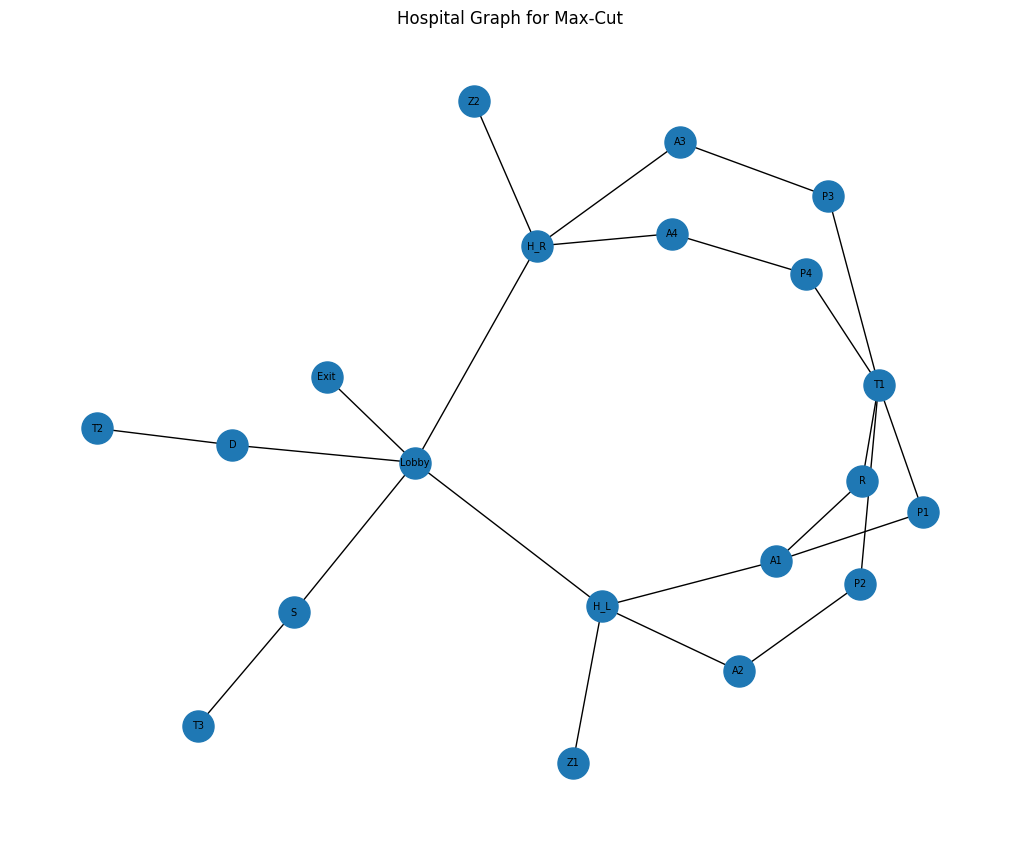

In [ ]:
G = nx.read_graphml("scenario_model (2).graphml")
G = G.to_undirected()
nx.set_edge_attributes(G, 1, "weight")

plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_size=500, font_size=7)
plt.title("Hospital Graph for Max-Cut")
plt.show()


In [ ]:
partition = maximum_cut(G, sampler=ExactSolver())
print("Max-Cut Partition groups (two lists):")
print(partition)



Max-Cut Partition groups (two lists):
{'S', 'H_R', 'P4', 'Exit', 'P2', 'P1', 'D', 'P3', 'R', 'H_L'}


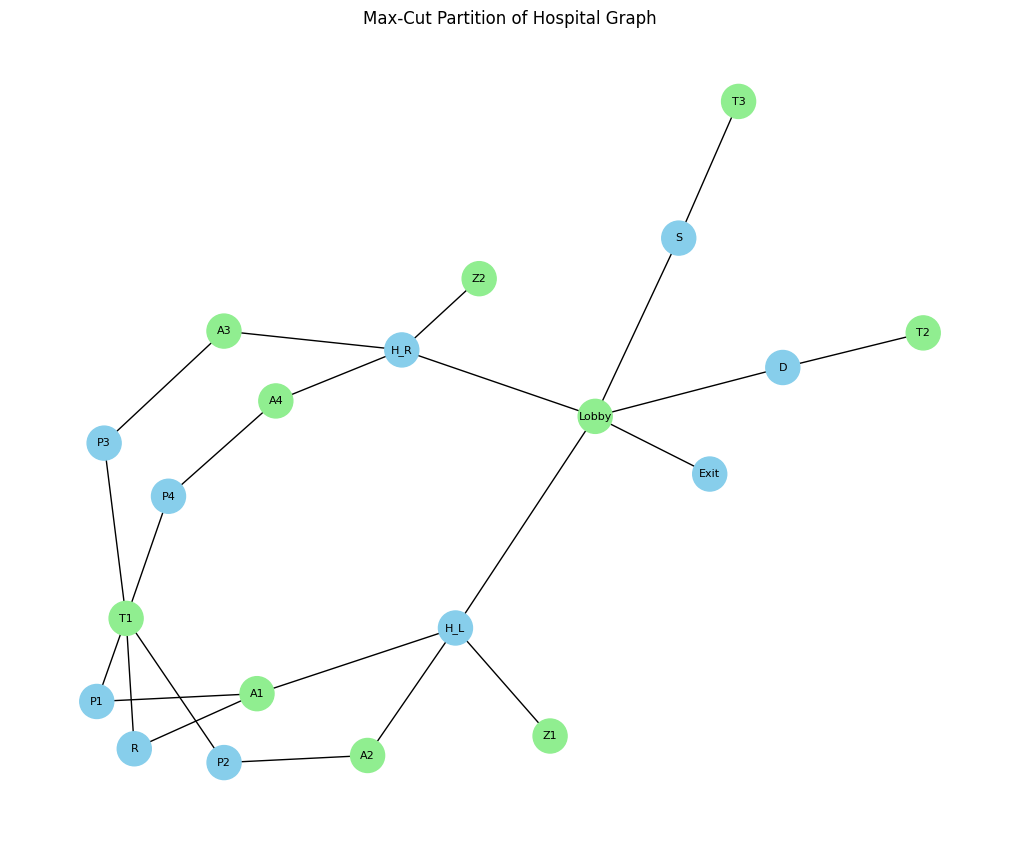

In [ ]:
# Draw partition result
color_map = []
for node in G.nodes():
    if node in partition:
        color_map.append("skyblue")
    else:
        color_map.append("lightgreen")

plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color=color_map, node_size=600, font_size=8)
plt.title("Max-Cut Partition of Hospital Graph")
plt.show()


In [ ]:
# Show unique node types in the full graph
node_types = set()

for _, data in G.nodes(data=True):
    node_type = data.get("type")
    if node_type:
        node_types.add(node_type)

print("Unique node types found in graph:", node_types)


Unique node types found in graph: {'staff', 'hazardous_zone', 'safe_zone', 'blocked_hallway', 'drone', 'room', 'robot'}


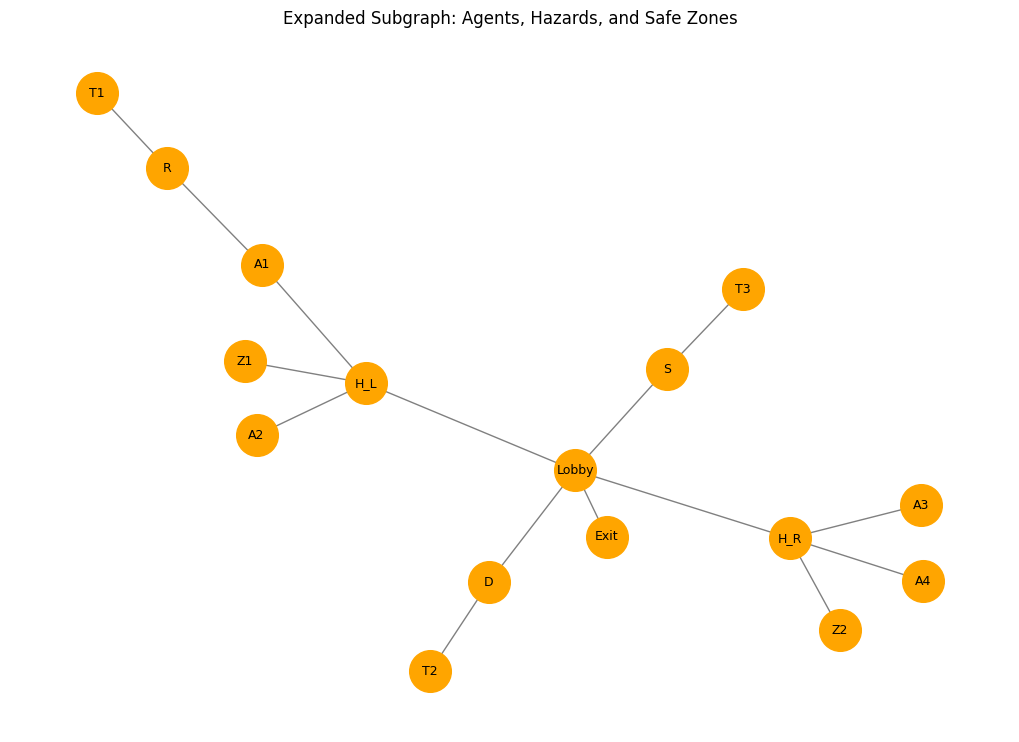

In [ ]:
#Experiment 2
# Define expanded roles
agent_types = {'robot', 'drone', 'staff'}
hazard_types = {'hazardous_zone', 'blocked_hallway'}
target_types = {'safe_zone'}

# Collect all relevant nodes
agent_nodes = [n for n, d in G.nodes(data=True) if d.get("type") in agent_types]
hazard_nodes = [n for n, d in G.nodes(data=True) if d.get("type") in hazard_types]
target_nodes = [n for n, d in G.nodes(data=True) if d.get("type") in target_types]

# Initial set
subgraph_nodes = set(agent_nodes + hazard_nodes + target_nodes)

# Add their neighbors
for node in list(subgraph_nodes):
    subgraph_nodes.update(G.neighbors(node))

# Create subgraph
routing_subgraph = G.subgraph(subgraph_nodes).copy()

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(routing_subgraph, seed=42)
nx.draw(
    routing_subgraph, pos, with_labels=True,
    node_color='orange', node_size=900,
    font_size=9, edge_color="gray"
)
plt.title("Expanded Subgraph: Agents, Hazards, and Safe Zones")
plt.show()



In [ ]:
import networkx as nx

# Define agents and destination
agents = [n for n, d in routing_subgraph.nodes(data=True) if d.get("type") in {"robot", "drone", "staff"}]
destination = "Exit"

# Compute paths
paths = {}
for agent in agents:
    try:
        path = nx.shortest_path(routing_subgraph, source=agent, target=destination)
        length = nx.shortest_path_length(routing_subgraph, source=agent, target=destination)
        paths[agent] = (path, length)
    except nx.NetworkXNoPath:
        paths[agent] = ("No path", None)

# Display results
for agent, (path, length) in paths.items():
    print(f"Agent {agent} path to {destination}: {path} | Distance: {length}")


Agent R path to Exit: ['R', 'A1', 'H_L', 'Lobby', 'Exit'] | Distance: 4
Agent S path to Exit: ['S', 'Lobby', 'Exit'] | Distance: 2
Agent D path to Exit: ['D', 'Lobby', 'Exit'] | Distance: 2
